# **MODELO XGBOOST (BASELINE)**

### **LIBRERIAS**

In [1]:
# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ==============================================================================

# --- Manipulación de Datos y Visualización ---
import pandas as pd                 # Para el manejo de datos tabulares, DataFrames y análisis exploratorio.
import numpy as np                  # Operaciones matriciales, vectores y arrays multidimensionales de alta eficiencia.
import matplotlib.pyplot as plt     # Gráficos simples.
import seaborn as sns               # Gráficos estadísticos complejos.

# --- Utilidades del Sistema y Flujo de Memoria ---
import os                           # Interacción con el SO y variables de entorno del equipo.
import joblib                       # Guardar (dump) objetos/preprocesadores grandes de Scikit-Learn.
import time                         # Evaluar latencias y cronometrar los scripts.
from tqdm import tqdm               # Barra de progreso durante iteraciones largas.
import gc                           # Garbage Collector: Borrado de la RAM 
import random                       # Aleatoriedad
from itertools import cycle         # Iterar infinitamente de un bloque circular de objetos y listas.
from pathlib import Path            # Mapear rutas del disco al SO.
import pickle                       # Estandarización Python pura 

# --- Deep Learning: TensorFlow y Keras ---
import tensorflow as tf     # Backend completo de IA para operaciones tensoriales.
from tensorflow.keras.models import Model, load_model   # API Computacional Funcional de Keras y Cargar Modelo.
from tensorflow.keras.optimizers import Adam            # Optimizador para ajustar la pérdida con gradiente estocástico.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint    # Métodos de vigilancia para parar de aprender si el loss del Valid se estanca.
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization               # Arquitectura para conectividad completa (Dense) y regularizadores del sobreajuste (Dropout/BatchNorm).
from tensorflow.keras.layers import LSTM, GRU, Bidirectional                                # Redes recurrentes: para el entendimiento temporal clásico e incubativo (memoria).
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, MaxPooling1D            # Redes convolucionales: capaces de detectar rápidamente caídas/subidas y picos de alerta sin basarse en contexto lejano.

# --- Machine Learning Numérico y Métricas Clásicas (Scikit-Learn) ---
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler    # Escalado físico y codificador binario para preparar features.
from sklearn.model_selection import train_test_split    # Realiza "Holdout"; es tu base real de división controlada en capas representativas (estratificadas).
from sklearn.utils import class_weight                  # Computa los desbalances permitiéndote penalizar en coste a la red por fallar las muestras extrañas.
from sklearn.preprocessing import label_binarize        # Binarización útil para análisis complejos ROC.
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score # Toolkit de evaluación técnica multiclase (Clasificación).
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # Toolkit para evaluación de regresión (El 'Grade de infeción' analóguco calculado).
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor      # Algoritmos Random-Forest a modo posible de modelo "tradicional" base a superar.
from xgboost import XGBClassifier, XGBRegressor

# --- Configuración Global ---
pd.set_option('display.max_columns', None)  # Muestra todas las columnas de df
np.random.seed(42)                          # Replicabilidad

# --- Configuración del contexto histórico del modelo ---
DIAS_CONTEXTO = 7                   # Días de contexto
WINDOW_SIZE = DIAS_CONTEXTO * 24    # Horas de contexto

### **CARGA DE DATOS**

In [2]:
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

### **PREPROCESAMIENTO (PIPELINE DE ETL)**

In [3]:
# ==============================================================================
# 1. ASEGURAR FORMATO
# ==============================================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)
    
# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# ==============================================================================
# 2. CODIFICACIÓN DE TARGETS
# ==============================================================================
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# ==============================================================================
# 3. SELECCIÓN DE VARIABLES
# ==============================================================================
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos', 
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# ==============================================================================
# 4. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# ==============================================================================
# 1. Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# 2. Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# 3. Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# 4. Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# ==============================================================================
# 5. ESCALADO (SOLO FIT EN TRAIN)
# ==============================================================================
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# ==============================================================================
# 6. GENERACIÓN Y APLANADO DE VENTANAS (ADAPTACIÓN PARA RF)
# ==============================================================================
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    
    # Agrupamos por planta para no mezclar los datos de una planta con otra
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float16)

# Usamos tu misma función 'crear_secuencias' para mantener la comparativa justa
print("\n🚀 Generando secuencias temporales...")
X_train_3d, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val_3d, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test_3d, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# IMPORTANTE: XGBoost no acepta 3D (Muestras, WINDOW_SIZE, 13). 
# Aplanamos a 2D
print("📦 Aplanando tensores para XGBoost...")
X_train_flat = X_train_3d.reshape(X_train_3d.shape[0], -1)
X_val_flat = X_val_3d.reshape(X_val_3d.shape[0], -1)
X_test_flat = X_test_3d.reshape(X_test_3d.shape[0], -1)

print(f"Nueva dimensionalidad: {X_train_flat.shape[1]} columnas por muestra.")

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Generando secuencias temporales...


📦 Aplanando tensores para XGBoost...
Nueva dimensionalidad: 2016 columnas por muestra.


0

## **ENTRENAMIENTO DEL XGBOOST**


🚀 Entrenando XGBoost Classifier en GPU...


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\callback.py:385: UserWarning: [09:18:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:2.16766	validation_1-mlogloss:2.17103
[20]	validation_0-mlogloss:1.82416	validation_1-mlogloss:1.87249
[40]	validation_0-mlogloss:1.67346	validation_1-mlogloss:1.75505
[60]	validation_0-mlogloss:1.57956	validation_1-mlogloss:1.69277
[80]	validation_0-mlogloss:1.51505	validation_1-mlogloss:1.65406
[100]	validation_0-mlogloss:1.46707	validation_1-mlogloss:1.62446
[120]	validation_0-mlogloss:1.42834	validation_1-mlogloss:1.60015
[140]	validation_0-mlogloss:1.39485	validation_1-mlogloss:1.58051
[160]	validation_0-mlogloss:1.36338	validation_1-mlogloss:1.56242
[180]	validation_0-mlogloss:1.33579	validation_1-mlogloss:1.54614
[200]	validation_0-mlogloss:1.30965	validation_1-mlogloss:1.53027
[220]	validation_0-mlogloss:1.28620	validation_1-mlogloss:1.51836
[240]	validation_0-mlogloss:1.26494	validation_1-mlogloss:1.50732
[260]	validation_0-mlogloss:1.24375	validation_1-mlogloss:1.49771
[280]	validation_0-mlogloss:1.22381	validation_1-mlogloss:1.48861
[300]	validation

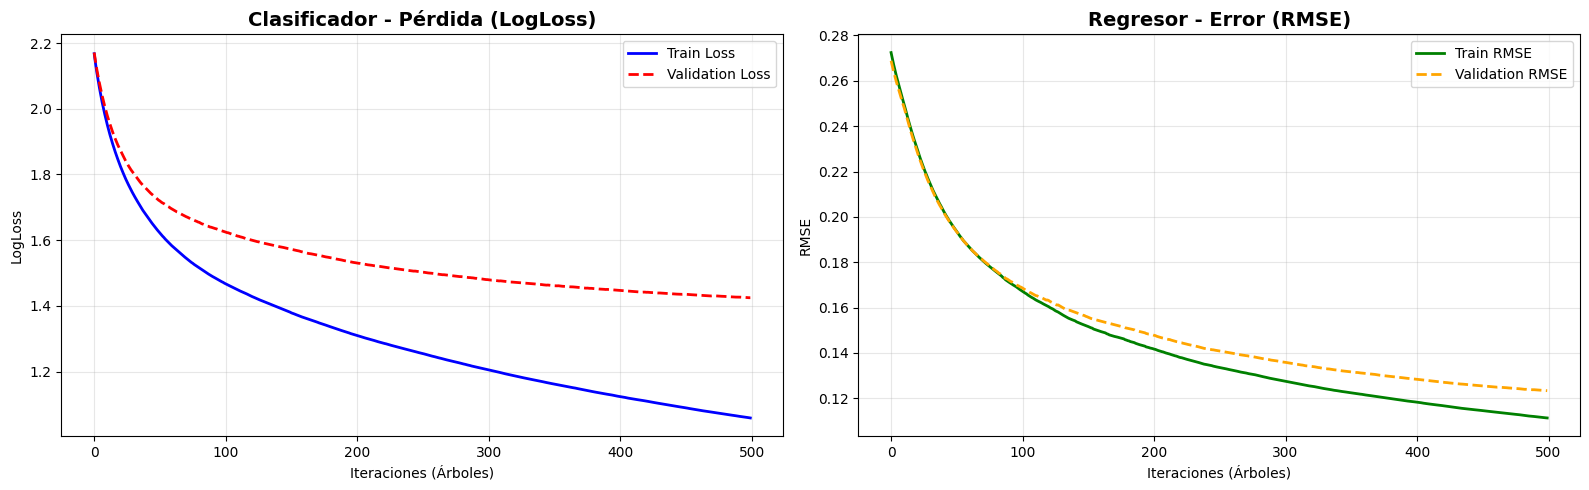

In [4]:
# ==============================================================================
# 7. DEFINICIÓN, ENTRENAMIENTO Y CURVAS DE APRENDIZAJE DE XGBOOST
# ==============================================================================

# --- A) CLASIFICADOR (Patologías) ---
print("\n🚀 Entrenando XGBoost Classifier en GPU...")
rf_class = XGBClassifier(
    n_estimators=500, 
    max_depth=4,
    min_samples_split = 8,
    min_samples_leaf = 8,
    learning_rate = 0.05,
    random_state=42,
    tree_method="hist", 
    device="cuda",
    early_stopping_rounds = 5,
    eval_metric="mlogloss" # Usamos log-loss para multiclase
)

# Entrenamos pasándole los conjuntos de Train y Valid para que monitorice
rf_class.fit(
    X_train_flat, y_train_class,
    eval_set=[(X_train_flat, y_train_class), (X_val_flat, y_val_class)],
    verbose=20 # Imprime por pantalla cada 10 árboles
)


# --- B) REGRESSOR (Grado de Infección) ---
print("\n🚀 Entrenando XGBoost Regressor en GPU...")
rf_reg = XGBRegressor(
    n_estimators=500, 
    max_depth=5, 
    learning_rate = 0.05,
    random_state=42,
    tree_method="hist",
    device="cuda",
    early_stopping_rounds = 5,
    eval_metric="rmse" # Usamos Error Cuadrático Medio para regresión
)

rf_reg.fit(
    X_train_flat, y_train_reg,
    eval_set=[(X_train_flat, y_train_reg), (X_val_flat, y_val_reg)],
    verbose=20
)

# ==============================================================================
# 7.1. GRÁFICAS DE CURVAS DE APRENDIZAJE
# ==============================================================================
print("\n📊 Generando curvas de aprendizaje...")

# Extraer los historiales de los modelos
hist_class = rf_class.evals_result()
hist_reg = rf_reg.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1: Pérdida del Clasificador (Multi-LogLoss)
axes[0].plot(hist_class['validation_0']['mlogloss'], label='Train Loss', color='blue', linewidth=2)
axes[0].plot(hist_class['validation_1']['mlogloss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
axes[0].set_title('Clasificador - Pérdida (LogLoss)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('LogLoss')
axes[0].set_xlabel('Iteraciones (Árboles)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Error del Regresor (RMSE)
axes[1].plot(hist_reg['validation_0']['rmse'], label='Train RMSE', color='green', linewidth=2)
axes[1].plot(hist_reg['validation_1']['rmse'], label='Validation RMSE', color='orange', linestyle='--', linewidth=2)
axes[1].set_title('Regresor - Error (RMSE)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Iteraciones (Árboles)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **EVALUACIÓN**


🧪 Evaluando XGBoost sobre datos de Test...


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:751: UserWarning: [09:23:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



🎯 MÉTRICAS DE CLASIFICACIÓN (XGBoost)
              precision    recall  f1-score   support

      ALTICA     0.6836    0.7957    0.7354      2859
   BLACK_ROT     0.4417    0.3012    0.3582     39132
    BOTRYTIS     0.3134    0.3827    0.3446     30119
    EMPOASCA     0.7286    0.7387    0.7337     23165
    ERINOSIS     0.3787    0.5138    0.4361     11556
        ESCA     0.4013    0.4072    0.4042     22053
     HEALTHY     0.4577    0.4982    0.4771     41117
     LOBESIA     0.4365    0.5467    0.4854     22824
      MILDIU     0.3012    0.2758    0.2879     20013
       OIDIO     0.7491    0.4873    0.5905      5968
    RED_MITE     0.1972    0.0174    0.0320      5568

    accuracy                         0.4417    224374
   macro avg     0.4626    0.4513    0.4441    224374
weighted avg     0.4420    0.4417    0.4350    224374



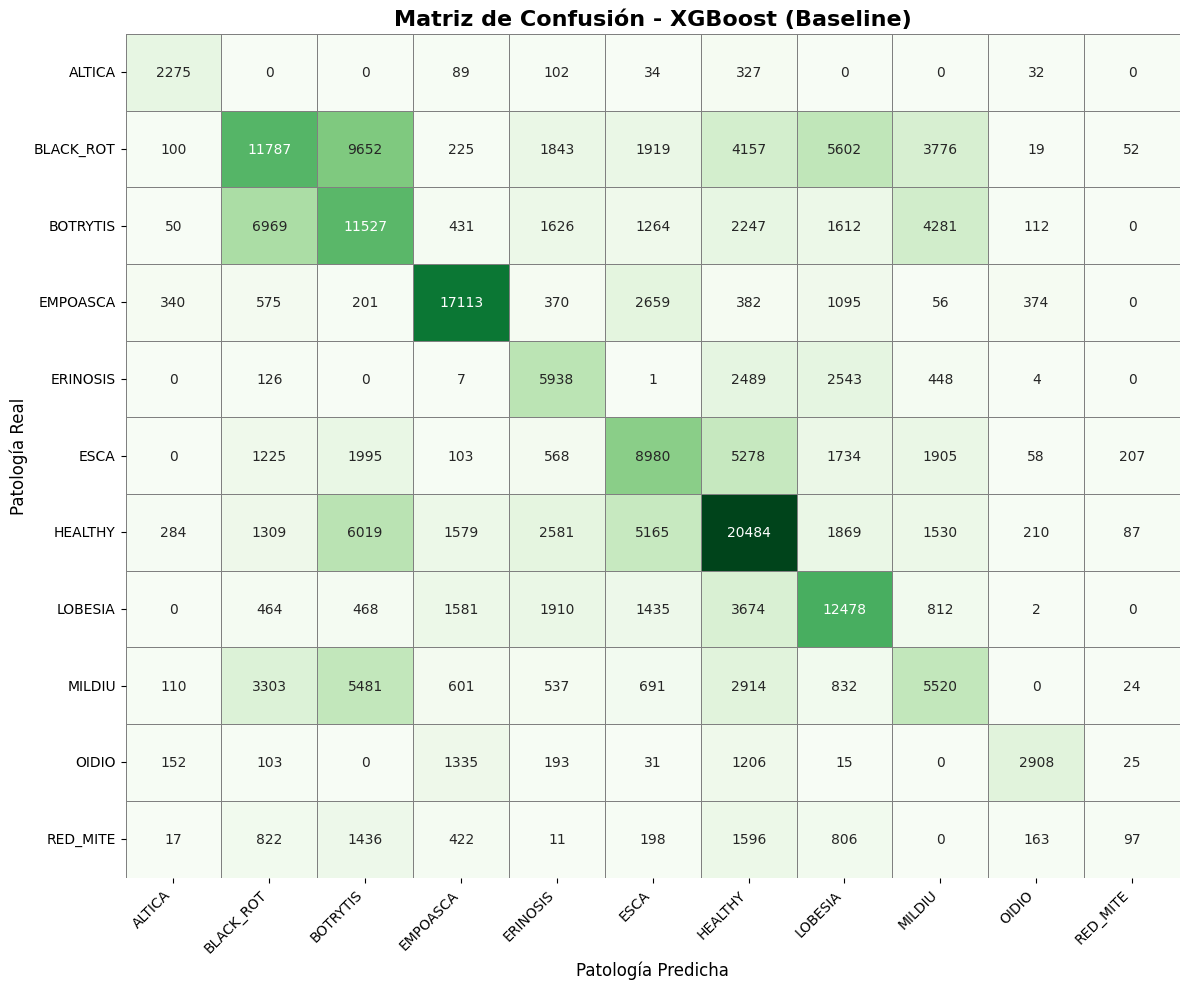


📈 MÉTRICAS DE REGRESIÓN (XGBoost)
MAE  (Mean Absolute Error):      0.0931  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0162  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.1273  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.7969  (Varianza explicada por el modelo. Max 1.0)


In [5]:
# ==============================================================================
# 8. EVALUACIÓN VISUAL Y MÉTRICAS
# ==============================================================================
print("\n🧪 Evaluando XGBoost sobre datos de Test...")

# 1. Inferencia Directa (Aplanada)
pred_clase_idx = rf_class.predict(X_test_flat)
pred_clase = le.inverse_transform(pred_clase_idx)
pred_confianza = np.max(rf_class.predict_proba(X_test_flat), axis=1)
pred_grado = rf_reg.predict(X_test_flat)

# 2. DataFrame de Resultados
resultados_test = pd.DataFrame({
    'Patología_Predicha': pred_clase,
    'Grado_Infeccion_Pred': pred_grado,
    'Confianza_IA': pred_confianza,
    'Patología_Real': le.inverse_transform(y_test_class),
    'Grado_Infeccion_Real': y_test_reg
})

# --- 1. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE CLASIFICACIÓN (XGBoost)")
print("="*50)

y_test_real_nombres = le.inverse_transform(y_test_class)

# Classification Report
reporte = classification_report(y_test_real_nombres, pred_clase, digits=4)
print(reporte)

# Matriz de Confusión
cm = confusion_matrix(y_test_real_nombres, pred_clase, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión - XGBoost (Baseline)', fontsize=16, fontweight='bold')
plt.ylabel('Patología Real', fontsize=12)
plt.xlabel('Patología Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (XGBoost)")
print("="*50)

mae = mean_absolute_error(y_test_reg, pred_grado)
mse = mean_squared_error(y_test_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

### **FEATURE IMPORTANCE**


📊 CALCULANDO IMPORTANCIA DE VARIABLES (AGRUPADA POR 168H)


C:\Users\User\AppData\Local\Temp\ipykernel_32520\77357031.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_class, x='Importancia', y='Variable', ax=axes[0], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_32520\77357031.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_reg, x='Importancia', y='Variable', ax=axes[1], palette='magma')


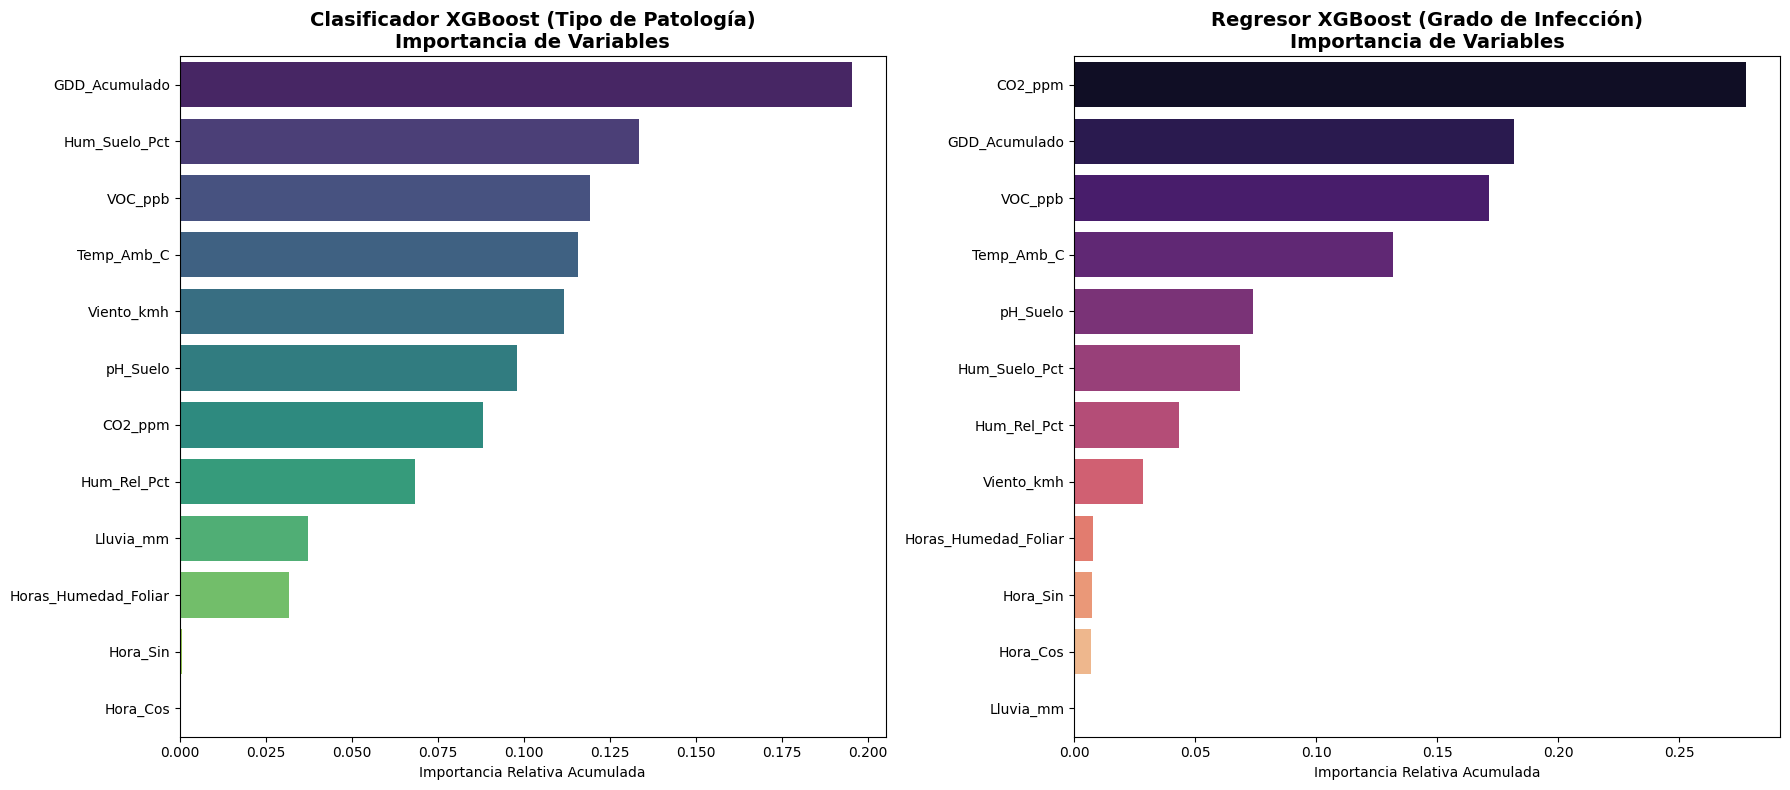

In [7]:
# ==============================================================================
# 9. IMPORTANCIA DE VARIABLES GLOBALES (FEATURE IMPORTANCE)
# ==============================================================================
print("\n" + "="*50)
print("📊 CALCULANDO IMPORTANCIA DE VARIABLES (AGRUPADA POR 168H)")
print("="*50)

# 1. Extraer importancias crudas (672 features aplanadas)
imp_class_flat = rf_class.feature_importances_
imp_reg_flat = rf_reg.feature_importances_

# 2. Reagrupar las importancias por variable física
# Convertimos de array (672,) a matriz (48, 14) y sumamos la dimensión temporal (eje 0)
imp_class_grouped = imp_class_flat.reshape(WINDOW_SIZE, len(cols_features)).sum(axis=0)
imp_reg_grouped = imp_reg_flat.reshape(WINDOW_SIZE, len(cols_features)).sum(axis=0)

# 3. Crear DataFrames ordenados para Seaborn
df_imp_class = pd.DataFrame({'Variable': cols_features, 'Importancia': imp_class_grouped})
df_imp_class = df_imp_class.sort_values(by='Importancia', ascending=False)

df_imp_reg = pd.DataFrame({'Variable': cols_features, 'Importancia': imp_reg_grouped})
df_imp_reg = df_imp_reg.sort_values(by='Importancia', ascending=False)

# 4. Generar la Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico 1: Clasificador (Patologías)
sns.barplot(data=df_imp_class, x='Importancia', y='Variable', ax=axes[0], palette='viridis')
axes[0].set_title('Clasificador XGBoost (Tipo de Patología)\nImportancia de Variables', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importancia Relativa Acumulada')
axes[0].set_ylabel('')

# Gráfico 2: Regresor (Grado de Infección)
sns.barplot(data=df_imp_reg, x='Importancia', y='Variable', ax=axes[1], palette='magma')
axes[1].set_title('Regresor XGBoost (Grado de Infección)\nImportancia de Variables', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importancia Relativa Acumulada')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()